# SECOM Dataset - Preprocessing

## Overview
Following EDA findings, we now prepare the data for modeling.
All preprocessing decisions are made on **training data only** to prevent data leakage.

### Preprocessing Pipeline
1. Train/Test Split
2. Drop high-missing features (fit on train only)
3. Correlation-based feature filtering (point-biserial vs label)
4. Imputation (fit on train, apply on test)
5. Scaling (fit on train, apply on test)
6. Handle class imbalance (SMOTE on train only)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import pointbiserialr


import sys
!{sys.executable} -m pip install imbalanced-learn

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [6]:
from pathlib import Path

project_root = Path.cwd() if (Path.cwd() / 'seacom_dataset').exists() else Path.cwd().parent
data_path = project_root / 'seacom_dataset' / 'secom.data'
labels_path = project_root / 'seacom_dataset' / 'secom_labels.data'

df = pd.read_csv(data_path, sep=' ', header=None)
labels = pd.read_csv(labels_path, sep=' ', 
                      header=None, names=['label', 'timestamp'])

# Attach label
df['outcome'] = labels['label']

X = df.drop(columns=['outcome'])
y = df['outcome']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nClass distribution:\n{y.value_counts()}")

X shape: (1567, 590)
y shape: (1567,)

Class distribution:
outcome
-1    1463
 1     104
Name: count, dtype: int64


## 3. Train / Test Split

We split **before any preprocessing** to prevent data leakage.

Key decisions:
- **test_size = 0.20** — 80/20 split, standard for this dataset size
- **stratify = y** — essential given 14:1 class imbalance, ensures both splits
  have proportional pass/fail representation
- **random_state = 42** — reproducibility

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")

Train shape: (1253, 590)
Test shape:  (314, 590)

Train class distribution:
outcome
-1    1170
 1      83
Name: count, dtype: int64

Test class distribution:
outcome
-1    293
 1     21
Name: count, dtype: int64


## 4. Drop High-Missing Features

We compute missing percentages **on train only** then apply the same
drop decision to test.

### Strategy (from EDA findings):
- Drop features with **>70% missing** AND **near-zero label correlation**
- Keep features with **>70% missing** if they show meaningful label correlation
  — these go to KNN imputation instead
- Use **point-biserial correlation** instead of Pearson — more appropriate
  for continuous feature vs binary label, and handles class imbalance better

In [9]:
import warnings
from scipy.stats import pointbiserialr

# Step 1 — compute missing % on train only
missing_pct_train = X_train.isnull().mean()

# Step 2 — compute point-biserial correlation with label on train only
correlations = {}
for col in X_train.columns:
    valid = X_train[[col]].copy()
    valid['label'] = y_train.values
    valid = valid.dropna()
    
    # Skip constant features or too sparse
    if len(valid) > 30 and valid[col].nunique() > 1:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            corr, _ = pointbiserialr(valid['label'], valid[col])
            correlations[col] = abs(corr)
    else:
        correlations[col] = np.nan

corr_series = pd.Series(correlations)

# Step 3 — build summary
feature_summary = pd.DataFrame({
    'missing_pct': missing_pct_train,
    'label_corr':  corr_series
})

# Step 4 — check distribution before setting threshold
high_missing = feature_summary[feature_summary['missing_pct'] > 0.70]
print(f"Features with >70% missing: {len(high_missing)}")
print(f"\nCorrelation stats for high-missing features:")
print(high_missing['label_corr'].describe())

Features with >70% missing: 8

Correlation stats for high-missing features:
count    8.000000
mean     0.087074
std      0.038569
min      0.040902
25%      0.050479
50%      0.086006
75%      0.125459
max      0.134111
Name: label_corr, dtype: float64


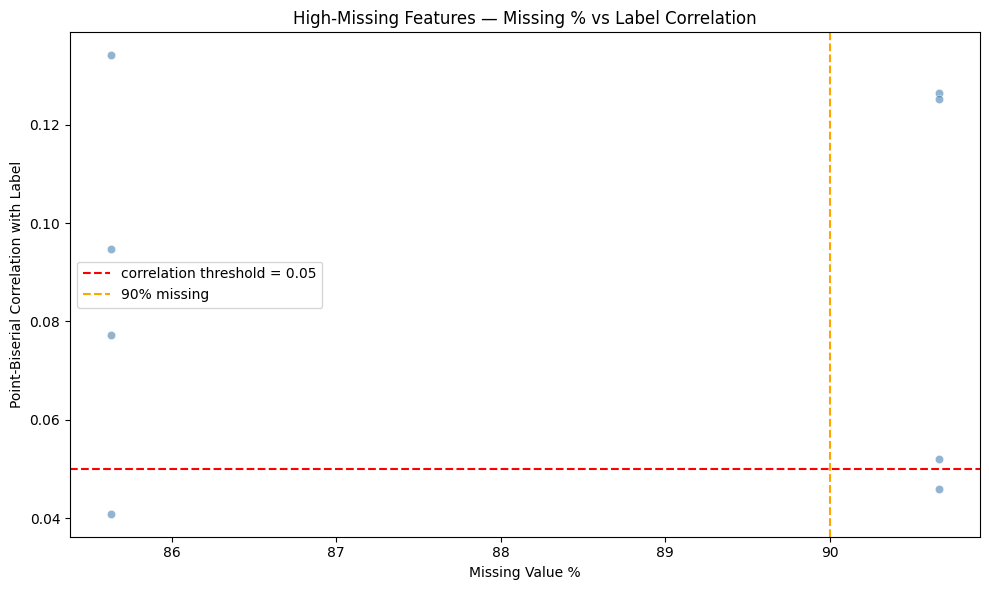

✅ Scatter plot saved

Features to drop: 2
Features remaining: 588
✅ Columns dropped from train and test


In [10]:


# Step 5 — scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(
    high_missing['missing_pct'] * 100,
    high_missing['label_corr'],
    alpha=0.6,
    color='steelblue',
    edgecolors='white',
    linewidths=0.5
)
plt.axhline(0.05, color='red', linestyle='--', label='correlation threshold = 0.05')
plt.axvline(90, color='orange', linestyle='--', label='90% missing')
plt.xlabel('Missing Value %')
plt.ylabel('Point-Biserial Correlation with Label')
plt.title('High-Missing Features — Missing % vs Label Correlation')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/missing_vs_corr.png', dpi=200)
plt.show()
print("✅ Scatter plot saved")

# Step 6 — drop features with >70% missing AND label correlation < 0.05
drop_mask = (feature_summary['missing_pct'] > 0.70) & \
            (feature_summary['label_corr'] < 0.05)

cols_to_drop = feature_summary[drop_mask].index.tolist()

print(f"\nFeatures to drop: {len(cols_to_drop)}")
print(f"Features remaining: {X_train.shape[1] - len(cols_to_drop)}")

X_train = X_train.drop(columns=cols_to_drop)
X_test  = X_test.drop(columns=cols_to_drop)

print("✅ Columns dropped from train and test")

In [13]:
import warnings
from scipy.stats import pointbiserialr

correlations = {}
for col in X_train.columns:
    valid = X_train[[col]].copy()
    valid['label'] = y_train.values
    valid = valid.dropna()
    
    # Skip constant features — correlation undefined
    if len(valid) > 30 and valid[col].nunique() > 1:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            corr, _ = pointbiserialr(valid['label'], valid[col])
            correlations[col] = abs(corr)
    else:
        correlations[col] = np.nan  # constant or too sparse

corr_series = pd.Series(correlations)
corr_series

0      0.020889
1      0.019620
2      0.024264
3      0.007885
4      0.010940
         ...   
585    0.001395
586    0.008901
587    0.051653
588    0.047695
589    0.014560
Length: 588, dtype: float64

## 5. Feature Summary — Missing % vs Label Correlation

We combine missing percentage and label correlation into one table,
then visualize to decide the drop threshold.

In [14]:
from pathlib import Path

project_root = Path.cwd() if (Path.cwd() / 'seacom_dataset').exists() else Path.cwd().parent
data_path = project_root / 'seacom_dataset' / 'secom.data'
labels_path = project_root / 'seacom_dataset' / 'secom_labels.data'

df = pd.read_csv(data_path, sep=' ', header=None)
labels = pd.read_csv(labels_path, sep=' ', 
                      header=None, names=['label', 'timestamp'])

# Attach label
df['outcome'] = labels['label']

X = df.drop(columns=['outcome'])
y = df['outcome']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nClass distribution:\n{y.value_counts()}")

X shape: (1567, 590)
y shape: (1567,)

Class distribution:
outcome
-1    1463
 1     104
Name: count, dtype: int64


### Distribution of Label Correlation Across All Features

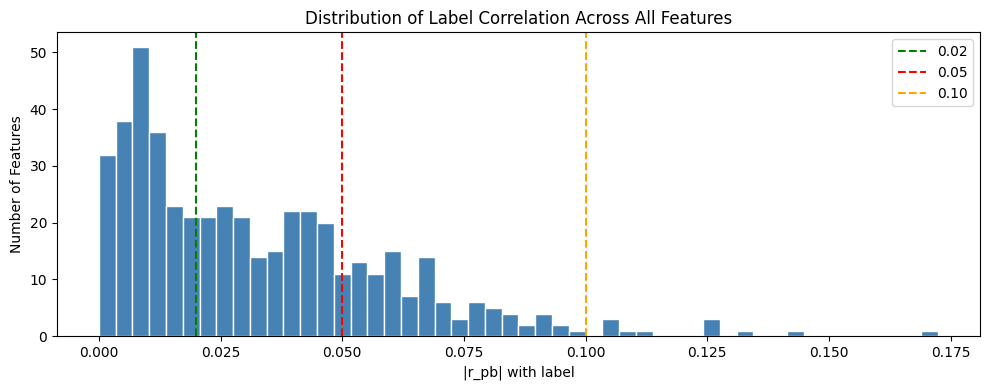

✅ Correlation distribution saved


In [19]:
# Step 2 — histogram of correlations
plt.figure(figsize=(10, 4))
plt.hist(feature_summary['label_corr'].dropna(), bins=50,
         color='steelblue', edgecolor='white')
plt.axvline(0.02, color='green',  linestyle='--', label='0.02')
plt.axvline(0.05, color='red',    linestyle='--', label='0.05')
plt.axvline(0.10, color='orange', linestyle='--', label='0.10')
plt.xlabel('|r_pb| with label')
plt.ylabel('Number of Features')
plt.title('Distribution of Label Correlation Across All Features')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/label_corr_dist.png', dpi=200)
plt.show()
print("✅ Correlation distribution saved")

### Missing % vs Label Correlation — Scatter Plot

Each dot = one feature.
- Bottom right → high missing, low correlation → **safe to drop**
- Top right → high missing, high correlation → **keep and impute**

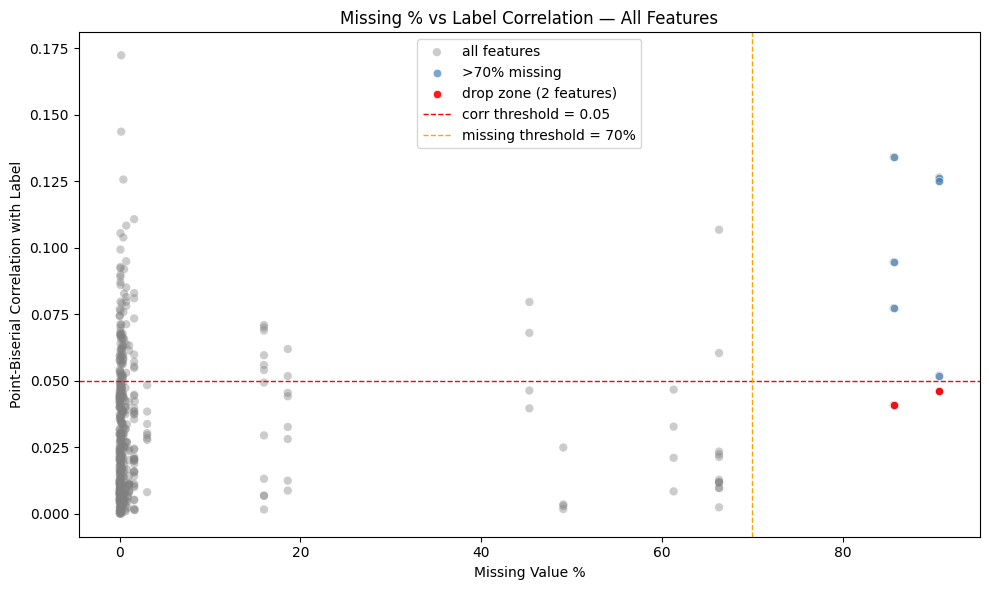

✅ Scatter plot saved


In [21]:
# Step 3 — scatter plot
fig, ax = plt.subplots(figsize=(10, 6))

# all features in grey
ax.scatter(
    feature_summary['missing_pct'] * 100,
    feature_summary['label_corr'],
    alpha=0.4,
    color='grey',
    edgecolors='none',
    label='all features'
)

# highlight high missing features in blue
high_missing = feature_summary[feature_summary['missing_pct'] > 0.70]
ax.scatter(
    high_missing['missing_pct'] * 100,
    high_missing['label_corr'],
    alpha=0.7,
    color='steelblue',
    edgecolors='white',
    linewidths=0.5,
    label='>70% missing'
)

# highlight drop zone in red
drop_zone = feature_summary[
    (feature_summary['missing_pct'] > 0.70) &
    (feature_summary['label_corr'] < 0.05)
]
ax.scatter(
    drop_zone['missing_pct'] * 100,
    drop_zone['label_corr'],
    alpha=0.9,
    color='red',
    edgecolors='white',
    linewidths=0.5,
    label=f'drop zone ({len(drop_zone)} features)'
)

ax.axhline(0.05, color='red',    linestyle='--', linewidth=1, label='corr threshold = 0.05')
ax.axvline(70,   color='orange', linestyle='--', linewidth=1, label='missing threshold = 70%')
ax.set_xlabel('Missing Value %')
ax.set_ylabel('Point-Biserial Correlation with Label')
ax.set_title('Missing % vs Label Correlation — All Features')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/missing_vs_corr.png', dpi=200)
plt.show()
print("✅ Scatter plot saved")

### Drop Decision

In [23]:
# Use .iloc based dropping instead
cols_to_drop_positions = [
    i for i, col in enumerate(feature_summary.index)
    if drop_mask[col]
]

# Get actual column names from X_train
cols_to_drop = [col for col in cols_to_drop if col in X_train.columns]

print(f"Features to drop: {len(cols_to_drop)}")

X_train = X_train.drop(columns=cols_to_drop)
X_test  = X_test.drop(columns=cols_to_drop)

print(f"✅ New X_train shape: {X_train.shape}")
print(f"✅ New X_test shape:  {X_test.shape}")

Features to drop: 0
✅ New X_train shape: (1253, 588)
✅ New X_test shape:  (314, 588)


In [25]:
# Recompute on updated X_train after dropping
high_missing_remaining = feature_summary.loc[X_train.columns][feature_summary.loc[X_train.columns]['missing_pct'] > 0.70]

print(f"Features with >70% missing AFTER dropping: {len(high_missing_remaining)}")
print(f"\nCorrelation breakdown:")
print(f"  r_pb < 0.05 : {(high_missing_remaining['label_corr'] < 0.05).sum()}")
print(f"  r_pb < 0.10 : {(high_missing_remaining['label_corr'] < 0.10).sum()}")
print(f"  r_pb < 0.15 : {(high_missing_remaining['label_corr'] < 0.15).sum()}")
print(f"  r_pb < 0.20 : {(high_missing_remaining['label_corr'] < 0.20).sum()}")

print(f"\nCorrelation values:")
print(high_missing_remaining['label_corr'].describe())

Features with >70% missing AFTER dropping: 6

Correlation breakdown:
  r_pb < 0.05 : 0
  r_pb < 0.10 : 3
  r_pb < 0.15 : 6
  r_pb < 0.20 : 6

Correlation values:
count    6.000000
mean     0.101610
std      0.032646
min      0.051961
25%      0.081666
50%      0.109908
75%      0.126115
max      0.134111
Name: label_corr, dtype: float64


## 6. Imputation — KNN Imputer

We use KNN imputation for all remaining missing values.
KNN finds the K most similar rows and uses their values to fill the gap.

**Fit on train only — applied to both train and test.**

In [26]:
from sklearn.impute import KNNImputer

print(f"Missing values in X_train before imputation: {X_train.isnull().sum().sum()}")
print(f"Missing values in X_test  before imputation: {X_test.isnull().sum().sum()}")

# Fit on train only
knn_imputer = KNNImputer(n_neighbors=5)

X_train_imputed = knn_imputer.fit_transform(X_train)
X_test_imputed  = knn_imputer.transform(X_test)

# Convert back to dataframe to keep column names
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)
X_test_imputed  = pd.DataFrame(X_test_imputed,  columns=X_test.columns)

print(f"\nMissing values in X_train after imputation: {X_train_imputed.isnull().sum().sum()}")
print(f"Missing values in X_test  after imputation: {X_test_imputed.isnull().sum().sum()}")
print(f"\n✅ KNN imputation complete")
print(f"X_train shape: {X_train_imputed.shape}")
print(f"X_test  shape: {X_test_imputed.shape}")

Missing values in X_train before imputation: 31659
Missing values in X_test  before imputation: 7522

Missing values in X_train after imputation: 0
Missing values in X_test  after imputation: 0

✅ KNN imputation complete
X_train shape: (1253, 588)
X_test  shape: (314, 588)


## 7. Standardization for PCA

We scale the imputed features before PCA because PCA is sensitive to feature scale.
Standardization puts every sensor on the same scale so that large-valued features do not dominate the principal components.
This gives us a cleaner feature space for the next reduction step.

In [ ]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imputed),
    columns=X_train_imputed.columns,
    index=X_train_imputed.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imputed),
    columns=X_test_imputed.columns,
    index=X_test_imputed.index
)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")
print(f"Train mean after scaling (first 5 cols):\n{X_train_scaled.iloc[:, :5].mean()}")
print(f"Train std after scaling (first 5 cols):\n{X_train_scaled.iloc[:, :5].std()}")


## 8. Why We Use PCA

We use PCA because the SECOM data has many sensor features that are likely correlated and partly redundant.
PCA compresses them into a smaller set of orthogonal components that keep most of the useful variation while reducing noise and overfitting risk.
Since PCA works on variance, we standardize first so every feature contributes fairly instead of letting large-scale features dominate.

In [27]:


results = []
for col in X_train_scaled.columns:
    corr, pval = pointbiserialr(y_train, X_train_scaled[col])
    results.append({'feature': col, 'correlation': corr, 'p_value': pval})

corr_df = pd.DataFrame(results).sort_values('correlation', key=abs, ascending=False)

significant = corr_df[corr_df['p_value'] < 0.05]
print(f"Significant features (p<0.05): {len(significant)} / {len(corr_df)}")
print(significant.head(20).to_string(index=False))


Significant features (p<0.05): 80 / 588
 feature  correlation      p_value
     103     0.172434 8.060053e-10
     510     0.143596 3.319127e-07
      59     0.125529 8.324752e-06
     348     0.110902 8.357701e-05
     129     0.108200 1.242955e-04
     431     0.105530 1.823770e-04
      64     0.104190 2.203568e-04
      21     0.099486 4.205873e-04
     125    -0.094258 8.359019e-04
     430     0.092841 1.001188e-03
     434     0.092378 1.061484e-03
     100     0.091995 1.113741e-03
     316    -0.089966 1.433169e-03
     435     0.089062 1.600941e-03
     436     0.087157 2.015473e-03
      28    -0.086083 2.290322e-03
     122    -0.084755 2.677439e-03
     351     0.083074 3.252747e-03
      95     0.083040 3.265596e-03
     124     0.081852 3.739430e-03


/Users/prathamtanti5163/miniforge3/envs/seacom/lib/python3.11/site-packages/scipy/stats/_stats_py.py:5523: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


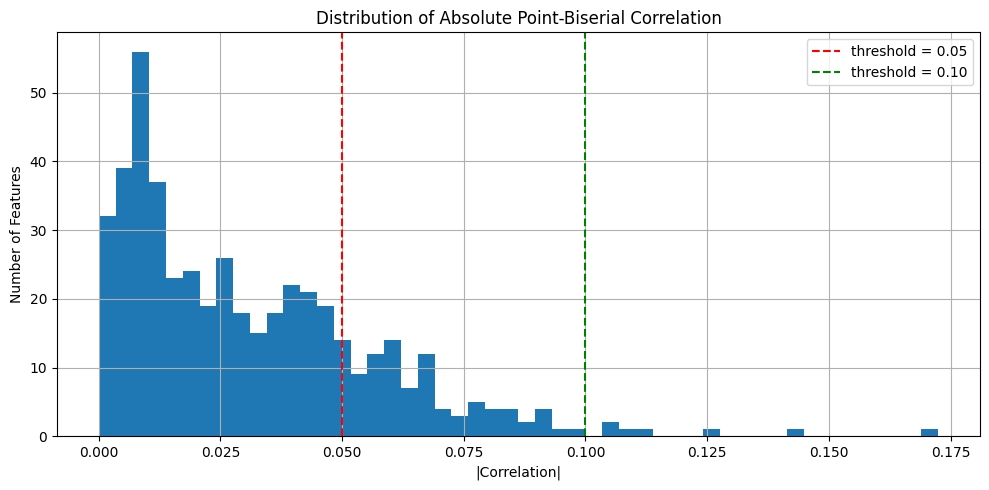

count    472.000000
mean       0.030782
std        0.025595
min        0.000038
25%        0.009601
50%        0.024787
75%        0.045623
max        0.172434
Name: correlation, dtype: float64

Features with |corr| >= 0.05: 95
Features with |corr| >= 0.08: 21
Features with |corr| >= 0.10: 7


In [28]:
plt.figure(figsize=(10, 5))
corr_df['correlation'].abs().hist(bins=50)
plt.xlabel('|Correlation|')
plt.ylabel('Number of Features')
plt.title('Distribution of Absolute Point-Biserial Correlation')
plt.axvline(x=0.05, color='r', linestyle='--', label='threshold = 0.05')
plt.axvline(x=0.10, color='g', linestyle='--', label='threshold = 0.10')
plt.legend()
plt.tight_layout()
plt.show()

print(corr_df['correlation'].abs().describe())
print(f"\nFeatures with |corr| >= 0.05: {(corr_df['correlation'].abs() >= 0.05).sum()}")
print(f"Features with |corr| >= 0.08: {(corr_df['correlation'].abs() >= 0.08).sum()}")
print(f"Features with |corr| >= 0.10: {(corr_df['correlation'].abs() >= 0.10).sum()}")


In [30]:
kept = (corr_df['correlation'].abs() >= 0.05).sum()
dropped = (corr_df['correlation'].abs() < 0.05).sum()
print(f"Kept:    {kept}")
print(f"Dropped: {dropped}")

Kept:    95
Dropped: 377
